# Quick analysis notebook: CLM5-PFT-PPE dataset

This notebook is designed for a short teaching exercise using `clm5-pft-ppe_dataset.nc`.

Main goals:

1. Open the NetCDF lazily with `xarray`.
2. Inspect dimensions, variables, and parameter metadata.
3. Plot simple model-output time series.
4. Compare ensemble spread for water-cycle variables such as ET and runoff.
5. Link shared/global parameter perturbations to simulated outputs with simple scatter/correlation plots.

The dataset is large (~25 GB), so the notebook uses lazy loading and small subsets where possible.


# Please download the full global data that include parameters and simulations of CLM here: https://zenodo.org/records/17178818

Note that this data only contains four model simulating variables: GPP, a water-stress indicator (BTRANMN), canopy transpiration (FCTR), and vegetation carbon storage (TOTVEGC)

In [20]:
# If needed, install packages first in your environment:
# conda install -c conda-forge xarray netcdf4 h5netcdf dask pandas numpy matplotlib cartopy scipy -y

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 6,
})
plt.rcParams["figure.dpi"] = 300

base_dir = Path("/Users/wantongli/Documents/work/teaching/Germany_May2026/teaching/teaching_code_WL/")
os.chdir(base_dir)


## 1. Set path and open the dataset

Put `clm5-pft-ppe_dataset.nc` in a folder and update `data_path` below.

Avoid `.load()` at the beginning because the file is large.


In [8]:
data_path = Path("CLM_PPE/clm5-pft-ppe_dataset.nc")  # <-- change this if needed

ds = xr.open_dataset(data_path, chunks="auto")   # lazy, does not load full file

ds


<xarray.Dataset> Size: 25GB
Dimensions:                      (ens: 500, time: 360, pft: 8574, lat: 96,
                                  lon: 144, gridcell: 400, landunit: 1267,
                                  column: 2974, param: 0, biome_id: 10,
                                  parameter: 32, pft_name: 16)
Coordinates:
  * time                         (time) object 3kB 1985-01-01 00:00:00 ... 20...
  * pft                          (pft) float64 69kB 0.0 1.0 2.0 ... 0.0 0.0 0.0
  * lat                          (lat) float32 384B -90.0 -88.11 ... 88.11 90.0
  * lon                          (lon) float32 576B 0.0 2.5 5.0 ... 355.0 357.5
  * gridcell                     (gridcell) int64 3kB 0 1 2 3 ... 397 398 399
  * biome_id                     (biome_id) int64 80B 0 1 2 3 4 5 6 7 8 9
  * parameter                    (parameter) <U19 2kB 'FUN_fracfixers' ... 'w...
  * pft_name                     (pft_name) <U35 2kB 'not_vegetated' ... 'c3_...
Dimensions without coordinates: ens, landunit, column, param
Data variables: (12/65)
    GPP                          (ens, time, pft) float32 6GB dask.array<chunksize=(500, 7, 8574), meta=np.ndarray>
    BTRANMN                      (ens, time, pft) float32 6GB dask.array<chunksize=(500, 7, 8574), meta=np.ndarray>
    FCTR                         (ens, time, pft) float32 6GB dask.array<chunksize=(500, 7, 8574), meta=np.ndarray>
    TOTVEGC                      (ens, time, pft) float32 6GB dask.array<chunksize=(500, 7, 8574), meta=np.ndarray>
    area                         (lat, lon) float32 55kB dask.array<chunksize=(96, 144), meta=np.ndarray>
    landfrac                     (lat, lon) float32 55kB dask.array<chunksize=(96, 144), meta=np.ndarray>
    ...                           ...
    PREC                         (time, gridcell) float32 576kB dask.array<chunksize=(360, 400), meta=np.ndarray>
    VPD                          (time, gridcell) float32 576kB dask.array<chunksize=(360, 400), meta=np.ndarray>
    VP                           (time, gridcell) float32 576kB dask.array<chunksize=(360, 400), meta=np.ndarray>
    biome                        (gridcell) float64 3kB dask.array<chunksize=(400,), meta=np.ndarray>
    biome_name                   (biome_id) <U32 1kB dask.array<chunksize=(10,), meta=np.ndarray>
    parameter_values_normalized  (ens, parameter, pft_name) float64 2MB dask.array<chunksize=(500, 32, 16), meta=np.ndarray>
Attributes:
    created_by:    linnia lh3194@columbia.edu
    created_on:    07/18/2025
    created_with:  /glade/u/home/linnia/clm5-pft-ppe/postprocess_data.ipynb
    github_repo:   https://github.com/linniahawkins/clm5-pft-ppe

# Total number of model output variables

In [9]:
import numpy as np
import pandas as pd

# -----------------------------
# 1. Print model output variables
# -----------------------------
# These are likely output variables because they have the ensemble dimension
# and are not parameter/metadata variables.
output_vars = []

for v in ds.data_vars:
    dims = ds[v].dims
    
    if "ens" in dims and v not in ["parameter_values_normalized", "key"]:
        output_vars.append(v)

print("Model output variables:")
print("-----------------------")
for v in output_vars:
    print(f"{v}: dims={ds[v].dims}, shape={ds[v].shape}, units={ds[v].attrs.get('units', 'NA')}")
    print(f"    long_name: {ds[v].attrs.get('long_name', 'NA')}")
    print()

print(f"Total number of model output variables: {len(output_vars)}")

Model output variables:
-----------------------
GPP: dims=('ens', 'time', 'pft'), shape=(500, 360, 8574), units=gC/m^2/s
    long_name: gross primary production

BTRANMN: dims=('ens', 'time', 'pft'), shape=(500, 360, 8574), units=unitless
    long_name: daily minimum of transpiration beta factor

FCTR: dims=('ens', 'time', 'pft'), shape=(500, 360, 8574), units=W/m^2
    long_name: canopy transpiration

TOTVEGC: dims=('ens', 'time', 'pft'), shape=(500, 360, 8574), units=gC/m^2
    long_name: total vegetation carbon, excluding cpool

Total number of model output variables: 4


# Total number of parameters
Interpretating refers to https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024MS004715 Table 2

In [10]:
# -----------------------------
# 2. Print all parameter names
# -----------------------------
param_names = ds["parameter"].values
pft_names = ds["pft_name"].values

print("Parameter names:")
print("----------------")
for i, p in enumerate(param_names):
    print(f"{i+1:02d}. {p}")

print(f"\nTotal number of parameters: {len(param_names)}")
print(f"Total number of PFTs: {len(pft_names)}")

Parameter names:
----------------
01. FUN_fracfixers
02. KCN
03. a_fix
04. crit_dayl
05. d_max
06. fff
07. froot_leaf
08. fstor2tran
09. grperc
10. jmaxb0
11. jmaxb1
12. kcha
13. kmax
14. krmax
15. leaf_long
16. leafcn
17. lmr_intercept_atkin
18. lmrha
19. lmrhd
20. medlynintercept
21. medlynslope
22. nstem
23. psi50
24. q10_mr
25. slatop
26. soilpsi_off
27. stem_leaf
28. sucsat_sf
29. theta_cj
30. tpu25ratio
31. tpuse_sf
32. wc2wjb0

Total number of parameters: 32
Total number of PFTs: 16


In [11]:
# -----------------------------
# 3. Print parameter value ranges
# -----------------------------
param_da = ds["parameter_values_normalized"]

rows = []

for p in param_names:
    x = param_da.sel(parameter=p)
    
    rows.append({
        "parameter": str(p),
        "min": float(x.min().compute()),
        "max": float(x.max().compute()),
        "mean": float(x.mean().compute()),
        "std": float(x.std().compute()),
        "n_unique": int(len(np.unique(x.values[~np.isnan(x.values)])))
    })

param_range_df = pd.DataFrame(rows)

display(param_range_df)

,parameter,min,max,mean,std,n_unique
0,FUN_fracfixers,0.000131,0.995722,0.443714,0.318153,100
1,KCN,0.000395,0.997342,0.536090,0.270696,100
2,a_fix,0.004254,0.987630,0.470831,0.289586,100
3,crit_dayl,0.004255,0.997471,0.529541,0.314532,100
4,d_max,0.008897,0.981447,0.479440,0.291340,100
5,fff,0.004669,0.976360,0.469469,0.299770,100
6,froot_leaf,0.000062,0.999780,0.542149,0.265145,5994
7,fstor2tran,0.002497,0.999027,0.486151,0.256778,100
8,grperc,0.014918,0.997888,0.539443,0.267670,100
9,jmaxb0,0.002831,0.980321,0.425257,0.282817,100


# Parameters across different Plant fanctional type (PFT) groups

In [12]:
# -----------------------------
# 4. Parameter value range by PFT
# -----------------------------
rows = []

for p in param_names:
    for pft in pft_names:
        x = param_da.sel(parameter=p, pft_name=pft)
        vals = x.values
        vals = vals[~np.isnan(vals)]
        
        if len(vals) == 0:
            rows.append({
                "parameter": str(p),
                "pft_name": str(pft),
                "min": np.nan,
                "max": np.nan,
                "mean": np.nan,
                "std": np.nan,
                "n_unique": 0
            })
        else:
            rows.append({
                "parameter": str(p),
                "pft_name": str(pft),
                "min": float(np.min(vals)),
                "max": float(np.max(vals)),
                "mean": float(np.mean(vals)),
                "std": float(np.std(vals)),
                "n_unique": int(len(np.unique(vals)))
            })

param_pft_range_df = pd.DataFrame(rows)

display(param_pft_range_df)

,parameter,pft_name,min,max,mean,std,n_unique
0,FUN_fracfixers,not_vegetated,0.000131,0.995722,0.443714,0.318153,100
1,FUN_fracfixers,needleleaf_evergreen_temperate_tree,0.000131,0.995722,0.443714,0.318153,100
2,FUN_fracfixers,needleleaf_evergreen_boreal_tree,0.000131,0.995722,0.443714,0.318153,100
3,FUN_fracfixers,needleleaf_deciduous_boreal_tree,0.000131,0.995722,0.443714,0.318153,100
4,FUN_fracfixers,broadleaf_evergreen_tropical_tree,0.000131,0.995722,0.443714,0.318153,100
...,...,...,...,...,...,...,...
507,wc2wjb0,broadleaf_deciduous_boreal_shrub,0.006770,0.994606,0.444608,0.304238,100
508,wc2wjb0,c3_arctic_grass,0.006770,0.994606,0.444608,0.304238,100
509,wc2wjb0,c3_non-arctic_grass,0.006770,0.994606,0.444608,0.304238,100
510,wc2wjb0,c4_grass,0.006770,0.994606,0.444608,0.304238,100


# Read and plot one clostest grid cell of Freiburg

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Target location: Freiburg
# -----------------------------
target_lat = 48.0
target_lon = 7.8

# -----------------------------
# 1. Load PFT coordinates into memory
# -----------------------------
pft_lat = ds["pfts1d_lat"].compute().values
pft_lon = ds["pfts1d_lon"].compute().values

# Handle longitude convention
target_lon_use = target_lon
if np.nanmax(pft_lon) > 180 and target_lon < 0:
    target_lon_use = target_lon + 360

# Distance to target location
dist2 = (pft_lat - target_lat) ** 2 + (pft_lon - target_lon_use) ** 2

# Get nearest PFT entries
n_nearest = 10
nearest_pft_idx = np.argsort(dist2)[:n_nearest]

print("Nearest PFT indices:")
print(nearest_pft_idx)

print("\nNearest PFT locations:")
for i in nearest_pft_idx:
    pft_type = int(ds["pfts1d_itype_veg"].isel(pft=i).compute().values)
    print(
        f"pft={int(i):5d}, "
        f"lat={pft_lat[i]:.3f}, "
        f"lon={pft_lon[i]:.3f}, "
        f"PFT type={pft_type}"
    )

Nearest PFT indices:
[5393 5394 5395 5396 5397 5398 5399 5400 5402 5403]

Nearest PFT locations:
pft= 5393, lat=50.211, lon=2.500, PFT type=0
pft= 5394, lat=50.211, lon=2.500, PFT type=1
pft= 5395, lat=50.211, lon=2.500, PFT type=2
pft= 5396, lat=50.211, lon=2.500, PFT type=3
pft= 5397, lat=50.211, lon=2.500, PFT type=4
pft= 5398, lat=50.211, lon=2.500, PFT type=5
pft= 5399, lat=50.211, lon=2.500, PFT type=6
pft= 5400, lat=50.211, lon=2.500, PFT type=7
pft= 5402, lat=50.211, lon=2.500, PFT type=9
pft= 5403, lat=50.211, lon=2.500, PFT type=10


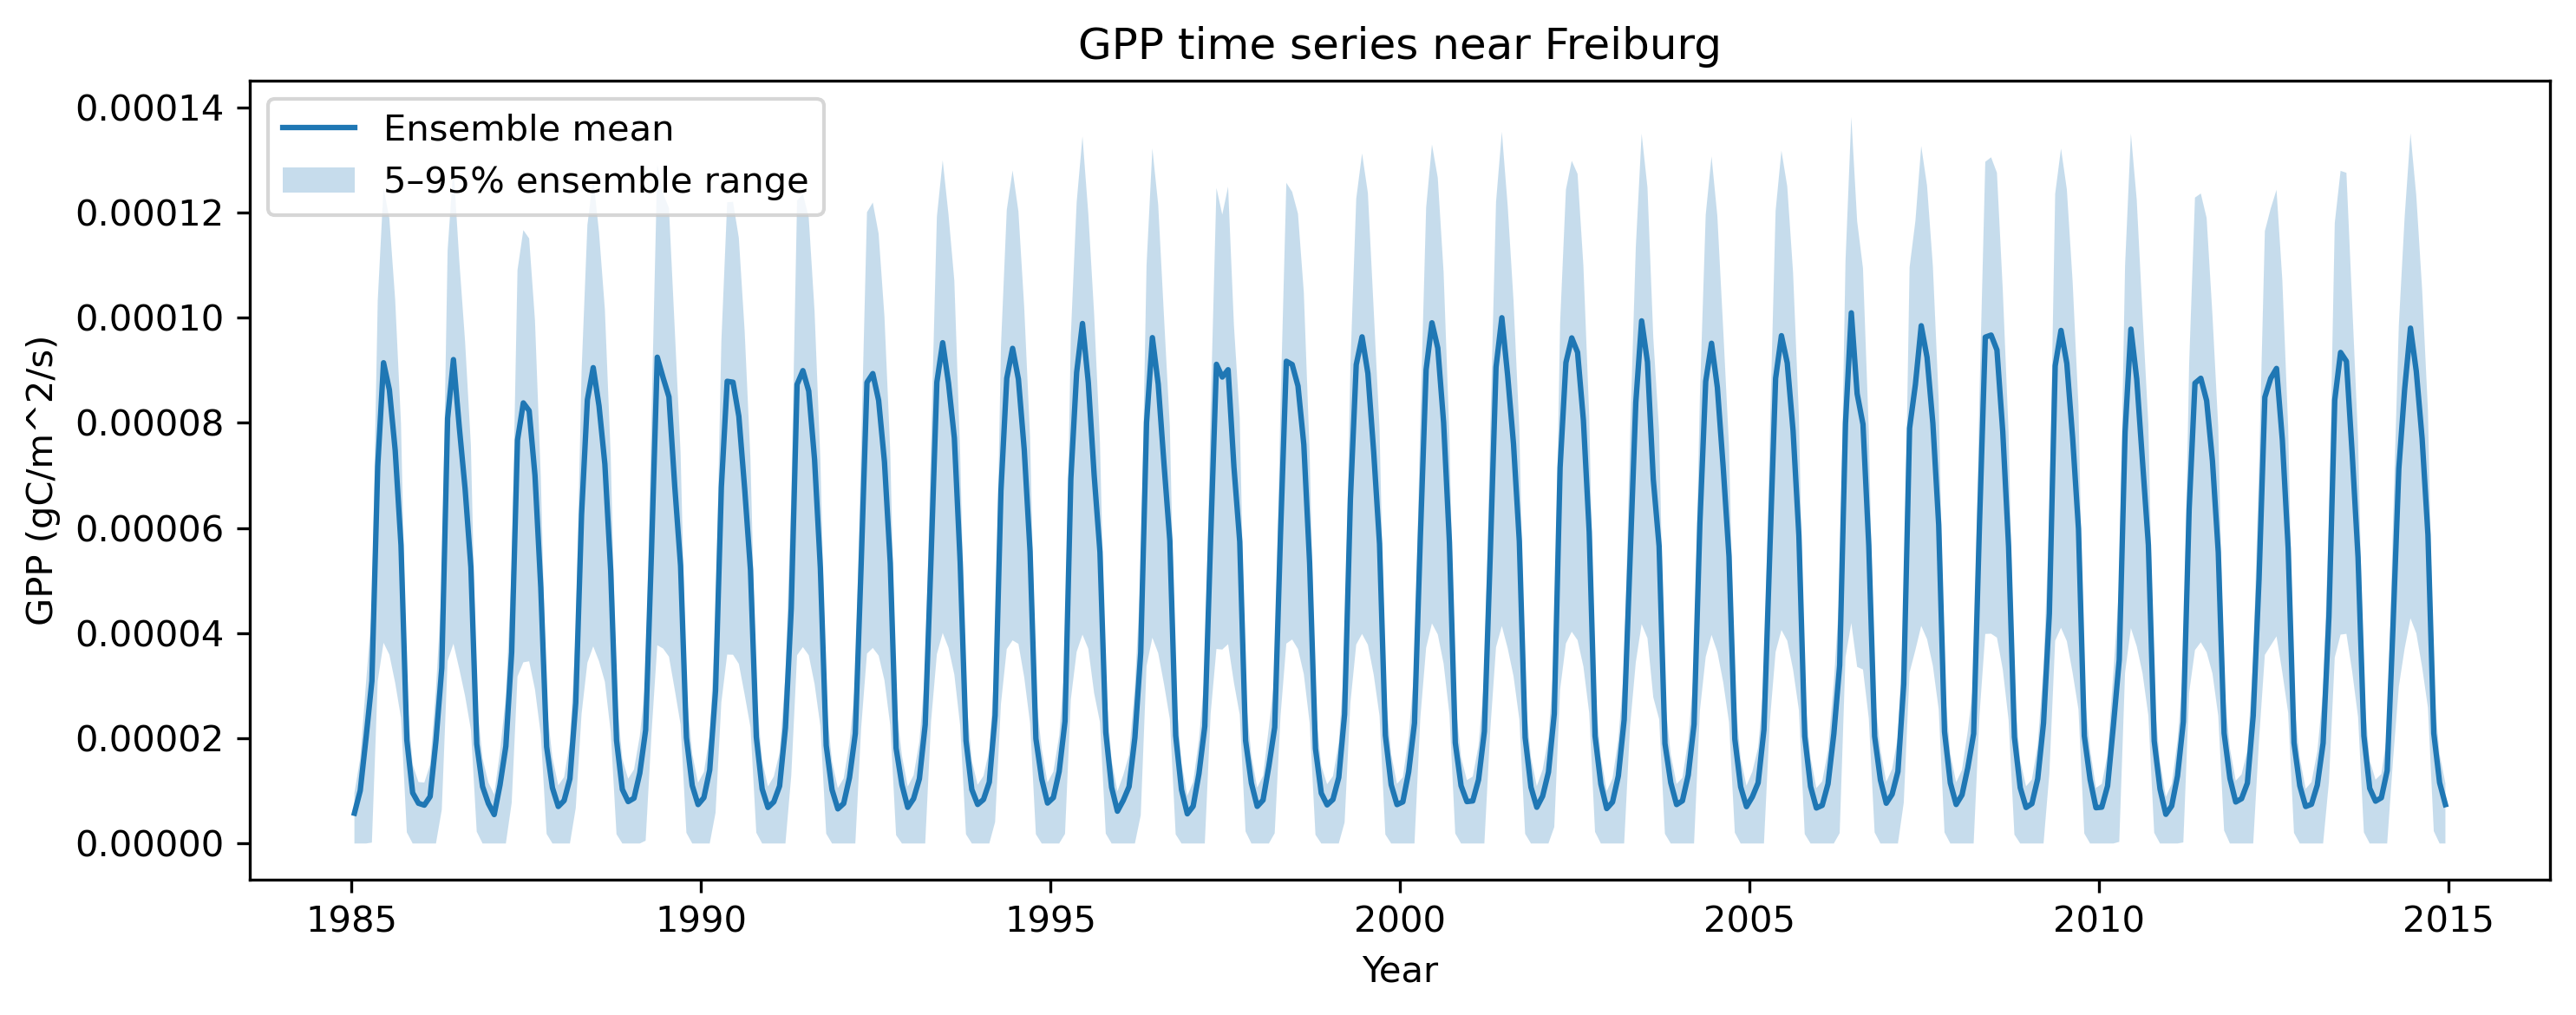

In [16]:
# -----------------------------
# Plot GPP time series using decimal year axis
# -----------------------------

# Convert cftime time to decimal year
time_vals = gpp_mean["time"].values
years = np.array([
    t.year + (t.month - 0.5) / 12
    for t in time_vals
])

plt.figure(figsize=(10, 4))

plt.plot(
    years,
    gpp_mean.values,
    label="Ensemble mean"
)

plt.fill_between(
    years,
    gpp_p05.values,
    gpp_p95.values,
    alpha=0.25,
    label="5–95% ensemble range"
)

plt.title("GPP time series near Freiburg")
plt.xlabel("Year")
plt.ylabel(f"GPP ({ds['GPP'].attrs.get('units', '')})")
plt.legend()
plt.tight_layout()
plt.show()

# Preliminary check on GPP sensitivity to jmaxb1, a Photosynthetic capacity parameter

Matching parameter names: ['jmaxb1']
Using parameter: jmaxb1
Nearest PFT indices: [5393 5394 5395 5396 5397 5398 5399 5400 5402 5403]


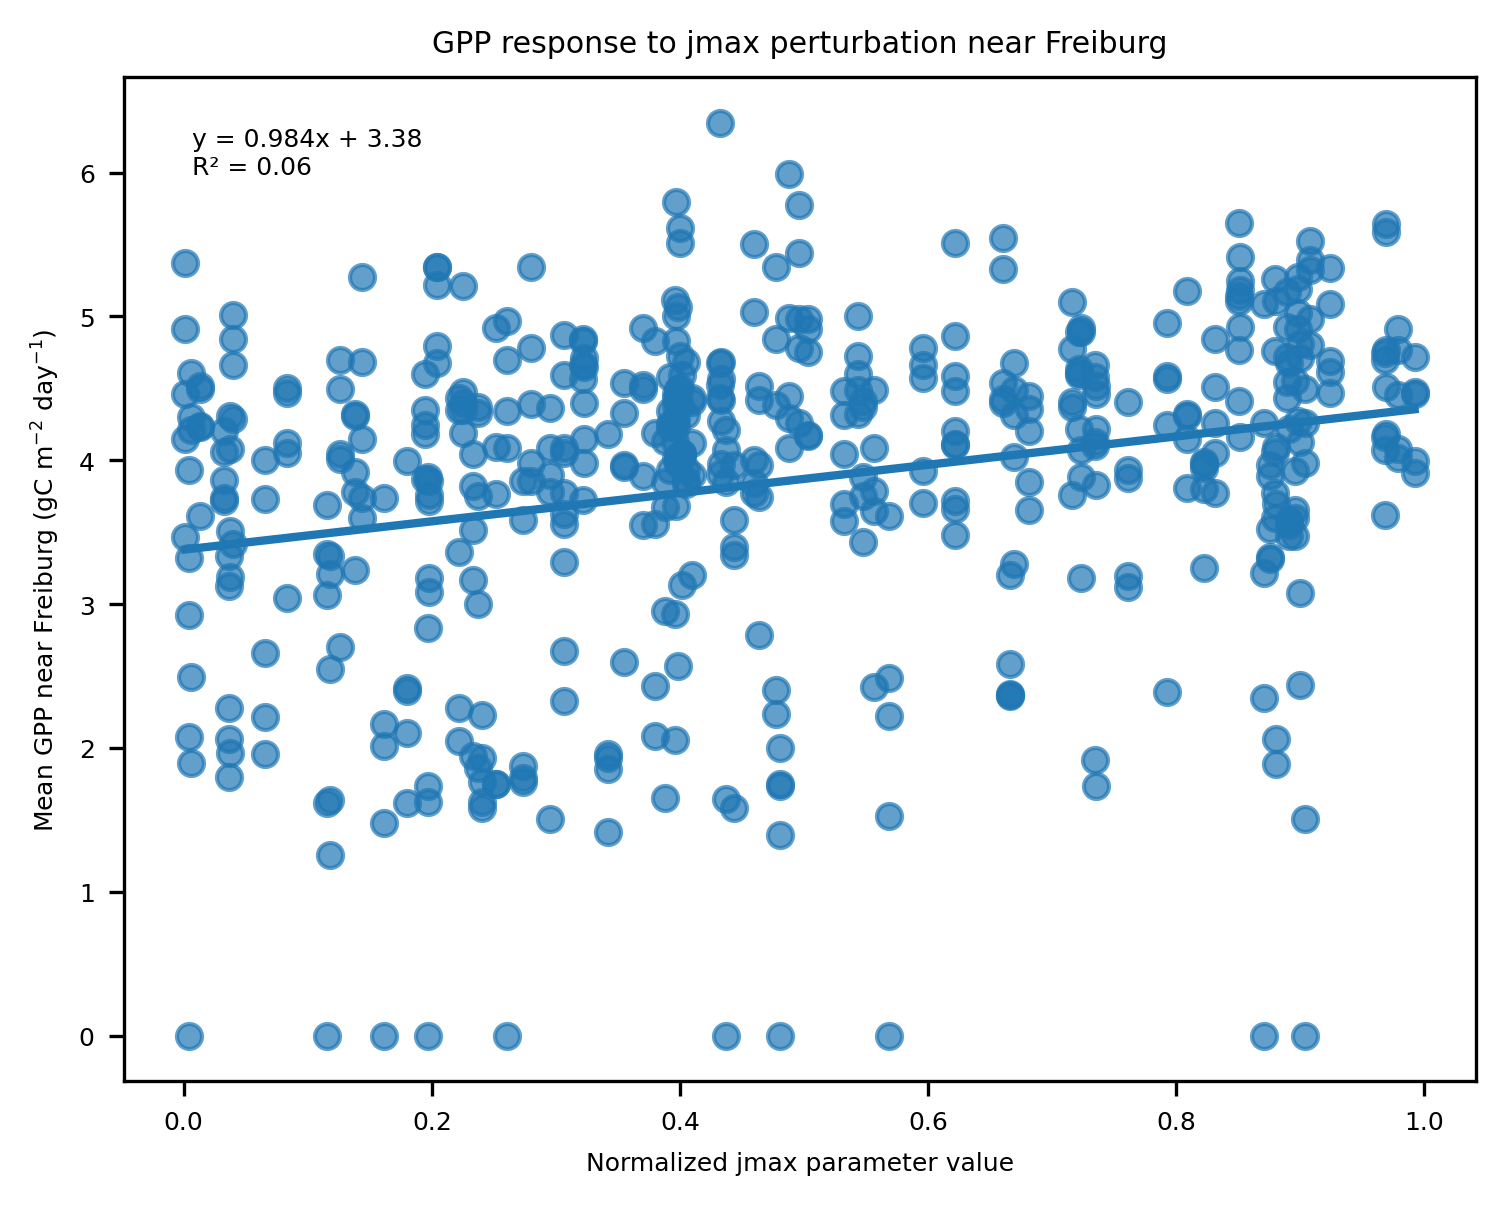

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
param_name = "jmaxb1"   # change if your parameter name is slightly different
target_lat = 48.0
target_lon = 7.8

# -----------------------------
# 1. Find the exact jmax parameter name
# -----------------------------
param_names = [str(p) for p in ds["parameter"].values]

matches = [p for p in param_names if "jmaxb1" in p.lower()]
print("Matching parameter names:", matches)

param_name = matches[0]
print("Using parameter:", param_name)

# -----------------------------
# 2. Find PFT entries near Freiburg
# -----------------------------
pft_lat = ds["pfts1d_lat"].compute().values
pft_lon = ds["pfts1d_lon"].compute().values

target_lon_use = target_lon
if np.nanmax(pft_lon) > 180 and target_lon < 0:
    target_lon_use = target_lon + 360

dist2 = (pft_lat - target_lat) ** 2 + (pft_lon - target_lon_use) ** 2

n_nearest = 10
nearest_pft_idx = np.argsort(dist2)[:n_nearest]

print("Nearest PFT indices:", nearest_pft_idx)

# -----------------------------
# 3. Get GPP near Freiburg
# -----------------------------
gpp = ds["GPP"].isel(pft=nearest_pft_idx)

# Optional: keep active PFTs only
if "pfts1d_active" in ds:
    active = ds["pfts1d_active"].isel(pft=nearest_pft_idx).compute()
    gpp = gpp.where(active == 1, drop=True)

# Mean over nearby PFT entries and time
gpp_mean = gpp.mean(dim=["time", "pft"]).compute()

# Convert GPP from gC/m2/s to gC/m2/day
gpp_mean_day = gpp_mean * 86400

# -----------------------------
# 4. Get jmax parameter values
# -----------------------------
# parameter_values_normalized has dims: ens, parameter, pft_name
jmax_vals_all_pfts = ds["parameter_values_normalized"].sel(parameter=param_name)

# Average jmax across all vegetated PFT names
# remove not_vegetated if present
if "not_vegetated" in ds["pft_name"].values:
    jmax_vals_all_pfts = jmax_vals_all_pfts.drop_sel(pft_name="not_vegetated")

jmax_vals = jmax_vals_all_pfts.mean(dim="pft_name").compute()

# -----------------------------
# 5. Plot GPP response to jmax perturbation
# -----------------------------
x = jmax_vals.values
y = gpp_mean_day.values

mask = np.isfinite(x) & np.isfinite(y)

coef = np.polyfit(x[mask], y[mask], 1)
xfit = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 100)
yfit = coef[0] * xfit + coef[1]

r = np.corrcoef(x[mask], y[mask])[0, 1]
r2 = r ** 2

plt.figure(figsize=(5,4))
plt.scatter(x[mask], y[mask], alpha=0.7)
plt.plot(xfit, yfit, linewidth=2)

plt.xlabel("Normalized jmax parameter value")
plt.ylabel("Mean GPP near Freiburg (gC m$^{-2}$ day$^{-1}$)")
plt.title("GPP response to jmax perturbation near Freiburg")

plt.text(
    0.05, 0.95,
    f"y = {coef[0]:.3g}x + {coef[1]:.3g}\nR² = {r2:.2f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

In [ ]:
bb